# Werner's Dune Model in 2D
Est. Runtime O(30 sec)

### Imports and Global Params

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.cm as cm
import numpy as np
from numpy import array, arange, mean, std, sqrt, power, zeros, ones
from numpy.random import default_rng
from scipy.stats import norm
from IPython.display import Video

Fontsize = 15

### Plotting Helper Func

In [2]:
def half_frame(ax, x_label, y_label, font_size=15):
    #Adapted from module_libraries.my_stats
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xlabel(x_label, fontsize=font_size)
    ax.set_ylabel(y_label, fontsize=font_size)
    ax.tick_params(labelsize=font_size - 2)

### Core Model

In [3]:
def initialize_surface(L):
    """Uniform flat bed of 1 slab per cell, Werner starting condition."""
    return np.ones((L, L), dtype=int)


def compute_shadow_zone(h, L, L_s, DirectionWind, shadow_angle=0.2):
    """
    Geometric shadow zone cast DOWNWIND of elevated cells.
    Fix from previous version: roll direction was inverted.
    """
    di, dj = DirectionWind
    inshadow = np.zeros((L, L), dtype=bool)

    for k in range(1, L_s + 1):
        # Height of cells k steps UPWIND of each cell
        upwind_h = np.roll(h, shift=(di * k, dj * k), axis=(0, 1))
        # A cell is shadowed if its upwind neighbor is tall enough
        inshadow |= (upwind_h > k * shadow_angle + h)

    return inshadow


def werner_step(h, L, p_erosion, L_s, DirectionWind,
                slope_threshold=4, shadow_angle=0.2,
                PdepNoShadow=0.6, rng=None):
    if rng is None:
        rng = default_rng()

    di, dj = DirectionWind

    # Compute shadow zone
    inshadow = compute_shadow_zone(h, L, L_s, DirectionWind, shadow_angle)

    #Erosion only from non-shadowed cells with sand
    can_erode  = (~inshadow) & (h > 0)
    erode_mask = can_erode & (rng.random((L, L)) < p_erosion)
    h -= erode_mask.astype(int)

    #Saltation: transport eroded slabs Ls downwind
    in_flight = erode_mask.astype(int)
    landed    = np.roll(in_flight, shift=(-di * L_s, -dj * L_s), axis=(0, 1))

    # Recompute shadow after erosion
    inshadow2 = compute_shadow_zone(h, L, L_s, DirectionWind, shadow_angle)

    #Deposition: certain in shadow, probabilistic outside
    Pdep     = np.where(inshadow2, 1.0, PdepNoShadow)
    deposit_here = landed.astype(bool) & (rng.random((L, L)) < Pdep)
    h           += deposit_here.astype(int)

    #Slabs that missed - one extra hop, then forced deposit
    StillFlying   = landed.astype(bool) & ~deposit_here
    second_landing = np.roll(StillFlying.astype(int),
                             shift=(-di * L_s, -dj * L_s), axis=(0, 1))
    h += second_landing

    #Avalanche
    for _ in range(2):
        for axis in [0, 1]:
            neighbor = np.roll(h, -1, axis=axis)
            diff     = h - neighbor
            transfer = (diff > slope_threshold).astype(int)
            h       -= transfer
            h       += np.roll(transfer, 1, axis=axis)

    np.clip(h, 0, None, out=h)


def run_werner(L, p_erosion, L_s, DirectionWind, Nsteps,
               slope_threshold=4, shadow_angle=0.2,
               PdepNoShadow=0.6, n_slabs=None,
                record_interval=10):

    rng_sim = default_rng()
    h = initialize_surface(L)

    history = [h.copy()]
    widths  = [float(np.std(h))]
    times   = [0]

    for step in range(1, Nsteps + 1):
        werner_step(h, L, p_erosion, L_s, DirectionWind,
                    slope_threshold=slope_threshold,
                    shadow_angle=shadow_angle,
                    PdepNoShadow=PdepNoShadow,
                    rng=rng_sim)
        if step % record_interval == 0:
            history.append(h.copy())
            widths.append(float(np.std(h)))
            times.append(step)

    return h, history, widths, times

### Analysis 1 Simulation - Code Validation

In [4]:
def measure_ripple_wavelength(h):
    L = h.shape[1]
    fft_rows = np.fft.rfft(h, axis=1)
    power_spectrum = np.mean(np.abs(fft_rows)**2, axis=0)
    freqs = np.fft.rfftfreq(L)
    power_spectrum[0] = 0
    peak_idx = np.argmax(power_spectrum)
    wavelength = 1.0 / freqs[peak_idx] if freqs[peak_idx] > 0 else float('inf')
    return wavelength, freqs, power_spectrum


L             = 128
p_erosion     = 0.5
PdepFlat    = 0.6
shadow_angle  = 0.2
Nsteps       = 600
DirectionWind      = (0, 1)
slope_thr     = 4
saltation_lengths = [8, 16, 32, 64]

print("Running Analysis 1: Ripple emergence and wavelength scaling...")
print(f"L={L}, p_erosion={p_erosion}, PdepNoShadow={PdepFlat}, "
      f"shadow_angle={shadow_angle}, Nsteps={Nsteps}")

final_surfaces   = {}
measured_lambdas = []

for L_s in saltation_lengths:
    print(f"  Running L_s = {L_s}...")
    h_final, _, _, _ = run_werner(
        L, p_erosion, L_s, DirectionWind, Nsteps,
        slope_threshold=slope_thr,
        shadow_angle=shadow_angle,
        PdepNoShadow=PdepFlat,
        record_interval=100
    )
    final_surfaces[L_s] = h_final
    lam, _, _ = measure_ripple_wavelength(h_final)
    measured_lambdas.append(lam)
    print(f"    Measured wavelength: {lam:.1f} cells")

print("Done.")

Running Analysis 1: Ripple emergence and wavelength scaling...
L=128, p_erosion=0.5, PdepNoShadow=0.6, shadow_angle=0.2, Nsteps=600
  Running L_s = 8...
    Measured wavelength: 8.5 cells
  Running L_s = 16...
    Measured wavelength: 18.3 cells
  Running L_s = 32...
    Measured wavelength: 42.7 cells
  Running L_s = 64...
    Measured wavelength: 128.0 cells
Done.


### Plot Analysis 1

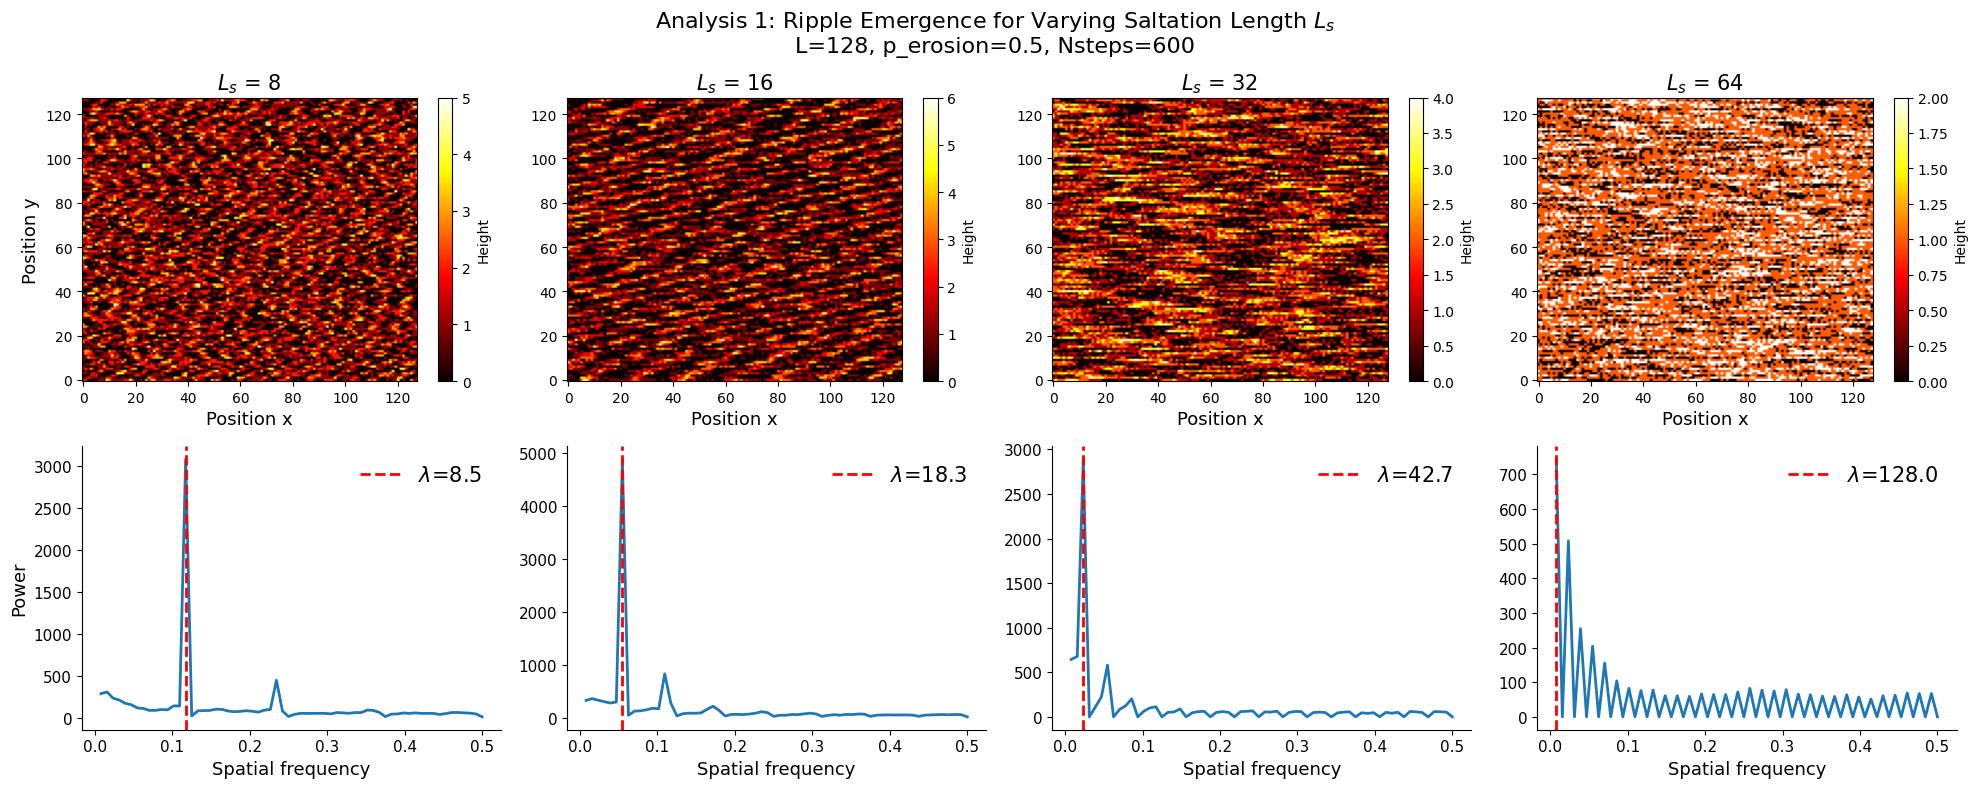

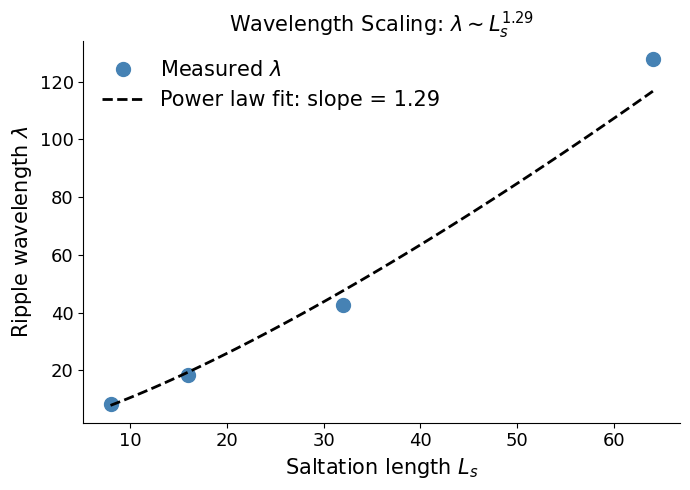

Power law fit exponent: 1.294


In [5]:
fig, axs = plt.subplots(2, 4, figsize=(20, 8))

# Top row: final height maps for each Ls
for k, L_s in enumerate(saltation_lengths):
    ax = axs[0, k]
    im = ax.imshow(final_surfaces[L_s], cmap='hot', origin='lower', aspect='auto')
    ax.set_title(f'$L_s$ = {L_s}', fontsize=Fontsize)
    ax.set_xlabel('Position x', fontsize=Fontsize - 2)
    if k == 0:
        ax.set_ylabel('Position y', fontsize=Fontsize - 2)
    plt.colorbar(im, ax=ax, label='Height')

# Bottom row: power spectra for each Ls
for k, L_s in enumerate(saltation_lengths):
    ax = axs[1, k]
    lam, freqs, power = measure_ripple_wavelength(final_surfaces[L_s])
    mask = freqs > 0
    half_frame(ax, 'Spatial frequency', 'Power' if k == 0 else '', Fontsize - 2)
    ax.plot(freqs[mask], power[mask], '-', lw=2)
    ax.axvline(1.0 / lam, color='r', lw=2, linestyle='--',
               label=f'$\\lambda$={lam:.1f}')
    ax.legend(frameon=False, fontsize=Fontsize)

fig.suptitle('Analysis 1: Ripple Emergence for Varying Saltation Length $L_s$\n'
             f'L={L}, p_erosion={p_erosion}, Nsteps={Nsteps}',
             fontsize=Fontsize + 1)
plt.tight_layout()
plt.show()

# --- Wavelength scaling plot ---
fig2, ax2 = plt.subplots(1, 1, figsize=(7, 5))
half_frame(ax2, 'Saltation length $L_s$', 'Ripple wavelength $\\lambda$', Fontsize)

ax2.plot(saltation_lengths, measured_lambdas, 'o', markersize=10,
         color='steelblue', label='Measured $\\lambda$')

# Fit a power law lambda ~ L_s^alpha
log_Ls  = np.log(saltation_lengths)
log_lam = np.log(measured_lambdas)
alpha, log_c = np.polyfit(log_Ls, log_lam, 1)
c = np.exp(log_c)
x_fit = np.linspace(saltation_lengths[0], saltation_lengths[-1], 100)
ax2.plot(x_fit, c * x_fit**alpha, 'k--', lw=2,
         label=f'Power law fit: slope = {alpha:.2f}')

ax2.legend(frameon=False, fontsize=Fontsize)
ax2.set_title(f'Wavelength Scaling: $\\lambda \\sim L_s^{{{alpha:.2f}}}$',
              fontsize=Fontsize)
plt.tight_layout()
plt.show()

print(f"Power law fit exponent: {alpha:.3f}")

### Extra Analysis 1

Running time evolution demo: L=128, L_s=16, snapshots at [0, 1, 2, 5, 20, 100]


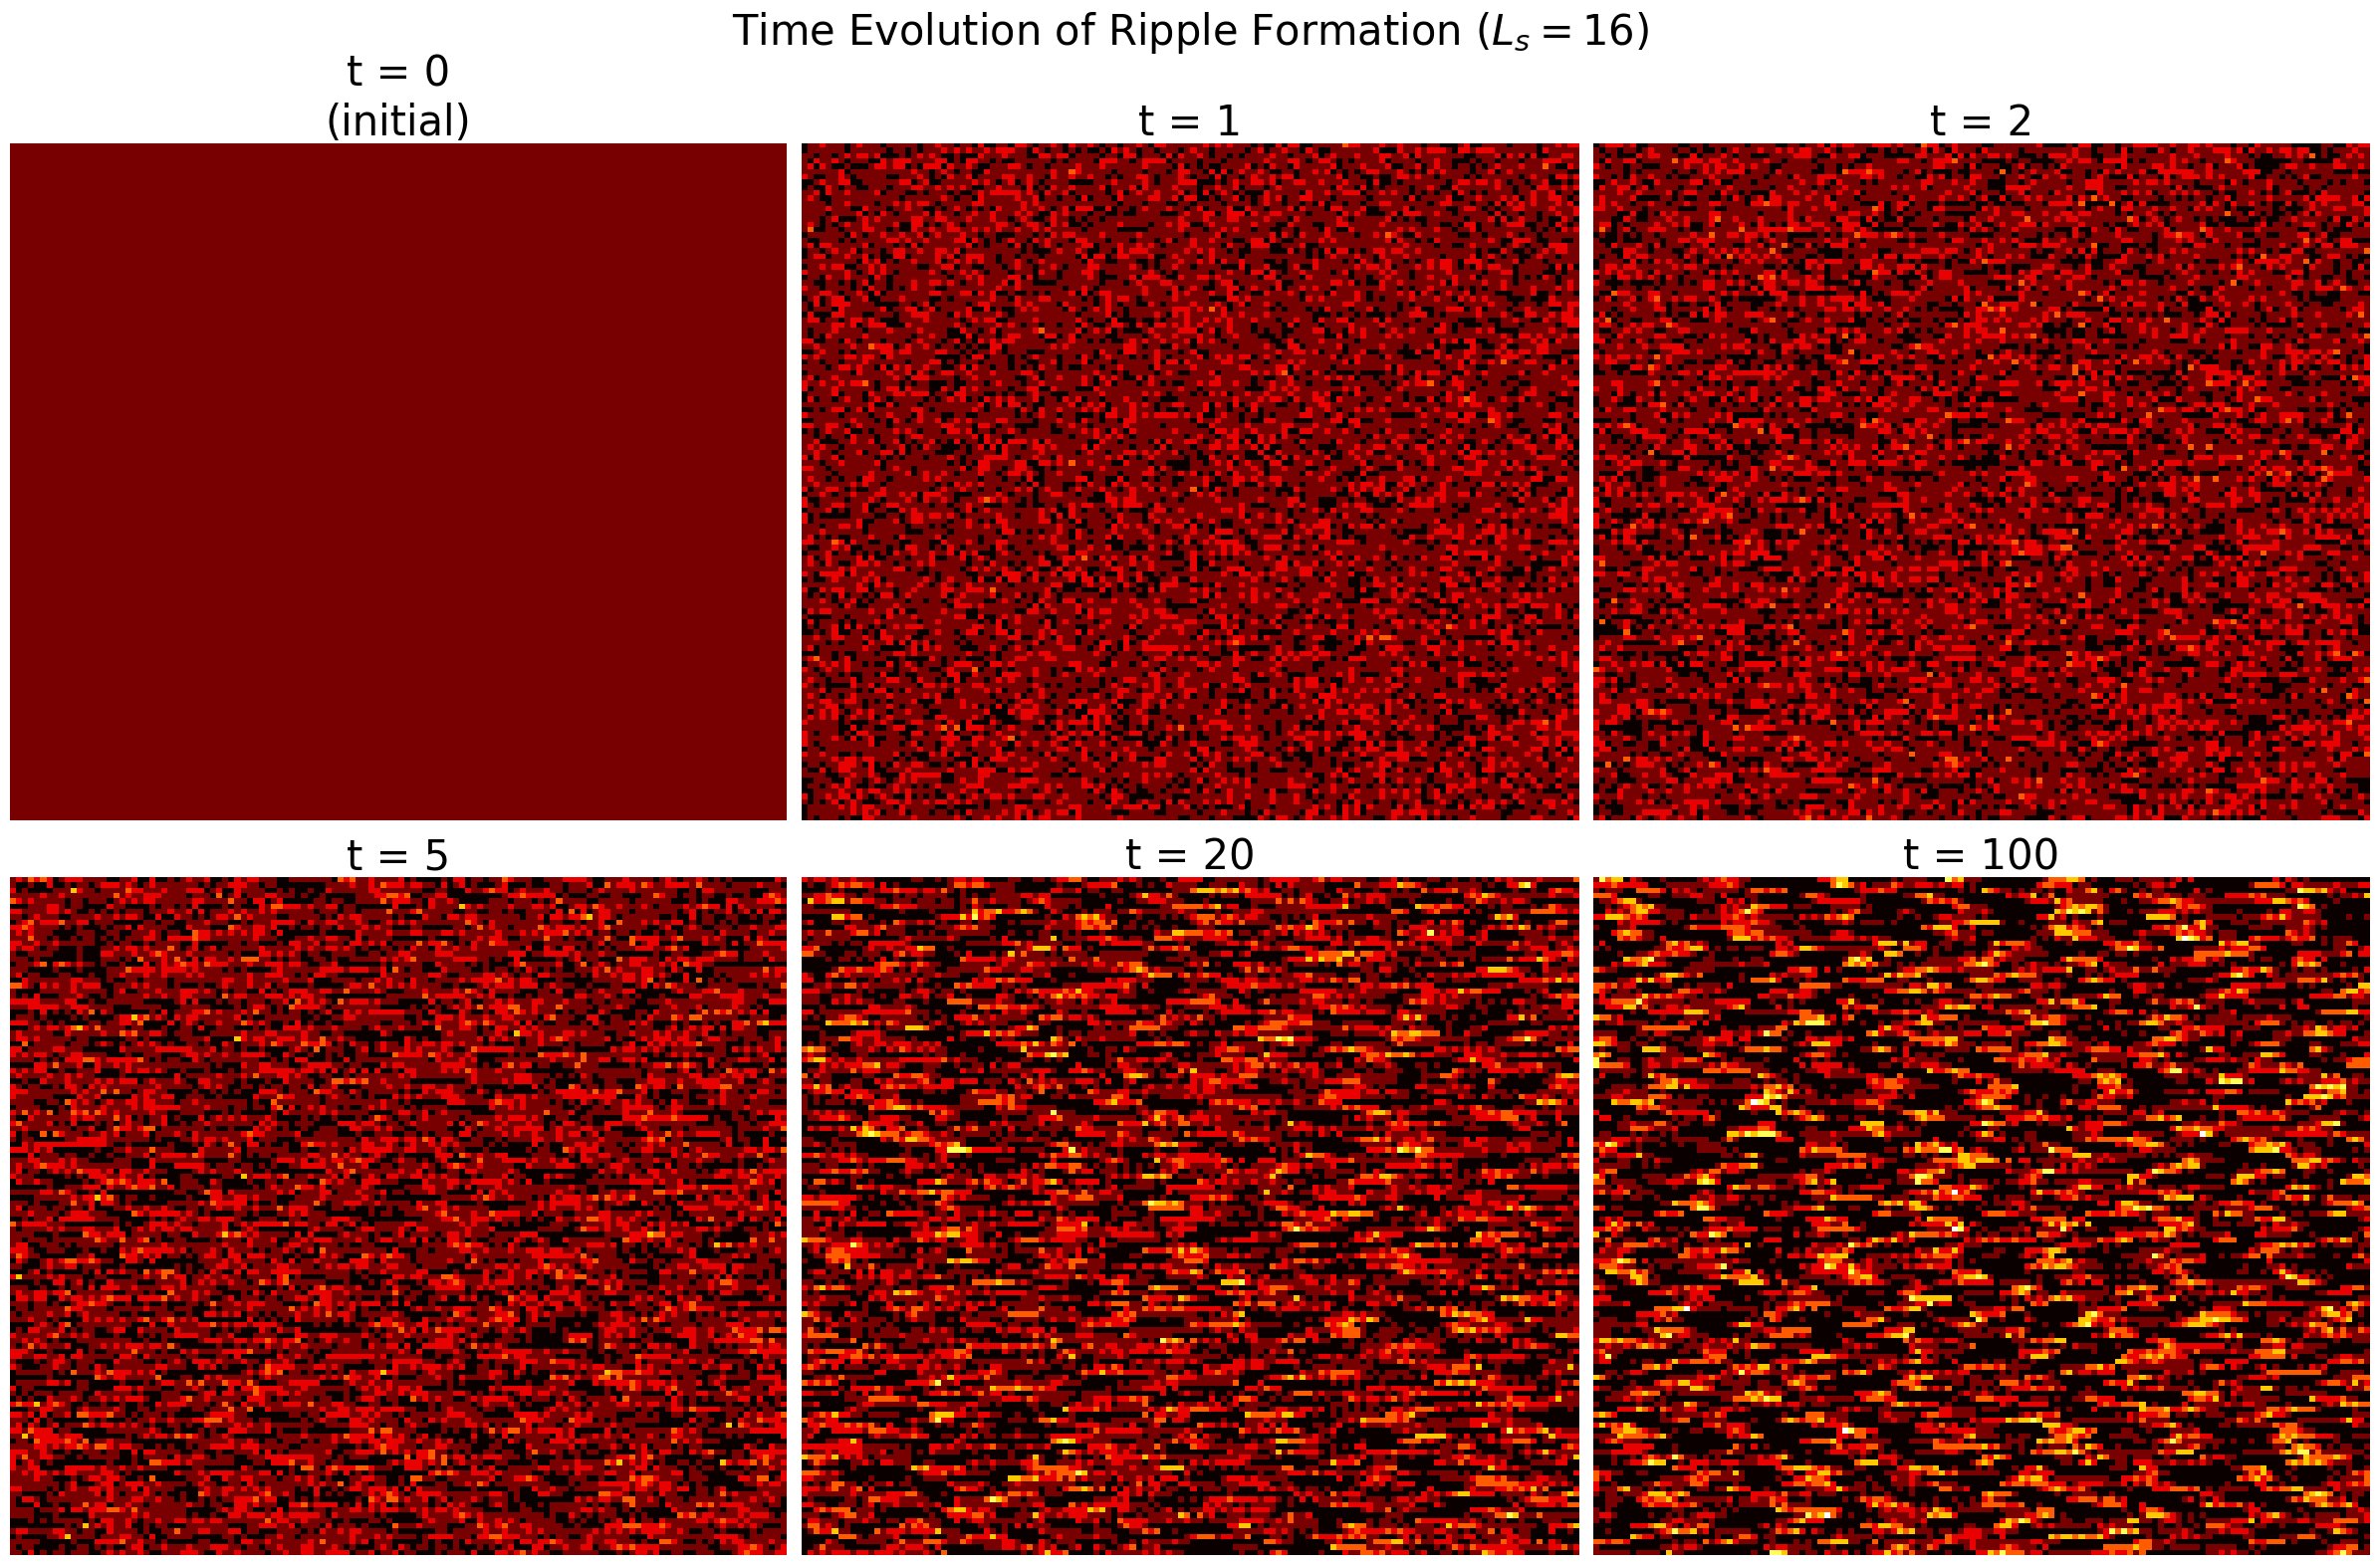

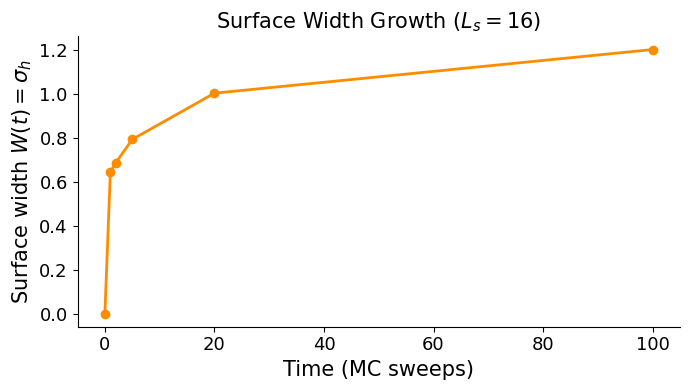

In [6]:
L_s_demo     = 16
snapshot_times = [0, 1, 2, 5, 20, 100]
Nsteps_demo   = max(snapshot_times)
print(f"Running time evolution demo: L={L}, L_s={L_s_demo}, "
      f"snapshots at {snapshot_times}")
# Run manually to capture exact timesteps
rng_demo = default_rng()
h_demo   = initialize_surface(L)
history_demo = []
widths_demo  = []
for step in range(Nsteps_demo + 1):
    if step in snapshot_times:
        history_demo.append(h_demo.copy())
        widths_demo.append(float(np.std(h_demo)))
    if step < Nsteps_demo:
        werner_step(h_demo, L, p_erosion, L_s_demo, DirectionWind,
                    slope_threshold=slope_thr,
                    shadow_angle=shadow_angle,
                    PdepNoShadow=PdepFlat,
                    rng=rng_demo)
#Snapshot grid
n_snapshots = len(snapshot_times)
fig, axs = plt.subplots(2, 3, figsize=(4 * n_snapshots, 16))
axs = axs.flatten()  # Fix - flatten 2D array of axes to 1D
vmin = min(h.min() for h in history_demo)
vmax = max(h.max() for h in history_demo)
for k, (snap, t) in enumerate(zip(history_demo, snapshot_times)):
    ax = axs[k]
    ax.imshow(snap, cmap='hot', origin='lower',
              vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(f't = {t}' + ('\n(initial)' if t == 0 else ''),
                 fontsize=30)
    ax.set_axis_off()
fig.suptitle(f'Time Evolution of Ripple Formation ($L_s={L_s_demo}$)',
             fontsize=30)
plt.tight_layout()
plt.show()
#Surface width
fig3, ax3 = plt.subplots(1, 1, figsize=(7, 4))
half_frame(ax3, 'Time (MC sweeps)', 'Surface width $W(t) = \\sigma_h$', Fontsize)
ax3.plot(snapshot_times, widths_demo, 'o-', lw=2, color='darkorange')
ax3.set_title(f'Surface Width Growth ($L_s={L_s_demo}$)', fontsize=Fontsize)
plt.tight_layout()
plt.show()

### Main Analysis 2 Simulation - 2D Werner

In [7]:
def run_werner_bidirectional(L, p_erosion, L_s, Nsteps,
                              switch_interval=100,
                              slope_threshold=4, shadow_angle=0.2,
                              PdepNoShadow=0.6,
                              record_interval=100):
    rng_sim = default_rng()
    h = initialize_surface(L)

    history = [h.copy()]
    widths  = [float(np.std(h))]
    times   = [0]
    directions = [(0, 1), (0, -1)]

    for step in range(1, Nsteps + 1):
        DirectionWind = directions[(step // switch_interval) % 2]
        werner_step(h, L, p_erosion, L_s, DirectionWind,
                    slope_threshold=slope_threshold,
                    shadow_angle=shadow_angle,
                    PdepNoShadow=PdepNoShadow,
                    rng=rng_sim)
        if step % record_interval == 0:
            history.append(h.copy())
            widths.append(float(np.std(h)))
            times.append(step)

    return h, history, widths, times


def angle_to_DirectionWind(angle_deg, L_s):
    """
    Convert a continuous angle in degrees to an integer (di, dj) offset
    by rounding the unit vector components scaled by L_s.
    This ensures the saltation hop covers approximately L_s cells
    regardless of direction.

    Parameters
    angle_deg : float - wind direction in degrees (0=right, 90=up, etc.)
    L_s       : int   - saltation length

    Returns
    (di, dj) : tuple of ints — row and column offset for np.roll
    """
    angle_rad = np.deg2rad(angle_deg)
    di = int(np.round(np.sin(angle_rad)))
    dj = int(np.round(np.cos(angle_rad)))
    # Prevent zero-vector in edge cases
    if di == 0 and dj == 0:
        dj = 1
    return (di, dj)


def run_werner_random_wind(L, p_erosion, L_s, Nsteps,
                            slope_threshold=4, shadow_angle=0.2,
                            PdepNoShadow=0.6,
                            record_interval=100):
    """
    Werner CA where wind direction is drawn from a uniform distribution
    over all 360 degrees at every timestep.
    """
    rng_sim = default_rng()
    h = initialize_surface(L)

    history = [h.copy()]
    widths  = [float(np.std(h))]
    times   = [0]

    for step in range(1, Nsteps + 1):
        # Draw a new wind direction uniformly from [0, 360)
        angle = rng_sim.uniform(0, 360)
        DirectionWind = angle_to_DirectionWind(angle, L_s)

        werner_step(h, L, p_erosion, L_s, DirectionWind,
                    slope_threshold=slope_threshold,
                    shadow_angle=shadow_angle,
                    PdepNoShadow=PdepNoShadow,
                    rng=rng_sim)
        if step % record_interval == 0:
            history.append(h.copy())
            widths.append(float(np.std(h)))
            times.append(step)

    return h, history, widths, times


L_a2           = 128
p_erosion_a2   = 0.5
PdepFlat     = 0.6
shadow_angle   = 0.2
L_s_a2         = 16
Nsteps_a2     = 600
slope_thr_a2   = 4

print("Running Analysis 2: Wind Regime Comparison")

print("  Running unidirectional wind (0,1)...")
h_uni, hist_uni, w_uni, t_uni = run_werner(
    L_a2, p_erosion_a2, L_s_a2, (0, 1), Nsteps_a2,
    slope_threshold=slope_thr_a2, shadow_angle=shadow_angle,
    PdepNoShadow=PdepFlat,
    record_interval=100
)

print("  Running bidirectional wind...")
h_bi, hist_bi, w_bi, t_bi = run_werner_bidirectional(
    L_a2, p_erosion_a2, L_s_a2, Nsteps_a2,
    switch_interval=100, slope_threshold=slope_thr_a2,
    shadow_angle=shadow_angle, PdepNoShadow=PdepFlat,
    record_interval=100
)

print("  Running oblique wind (1,1)...")
h_obl, hist_obl, w_obl, t_obl = run_werner(
    L_a2, p_erosion_a2, L_s_a2, (1, 1), Nsteps_a2,
    slope_threshold=slope_thr_a2, shadow_angle=shadow_angle,
    PdepNoShadow=PdepFlat,
    record_interval=100
)

print("  Running random wind (uniform 0-360 degrees)...")
h_rnd, hist_rnd, w_rnd, t_rnd = run_werner_random_wind(
    L_a2, p_erosion_a2, L_s_a2, Nsteps_a2,
    slope_threshold=slope_thr_a2, shadow_angle=shadow_angle,
    PdepNoShadow=PdepFlat,
    record_interval=100
)

print("Done.")

Running Analysis 2: Wind Regime Comparison
  Running unidirectional wind (0,1)...
  Running bidirectional wind...
  Running oblique wind (1,1)...
  Running random wind (uniform 0-360 degrees)...
Done.


### Plot Analysis 2

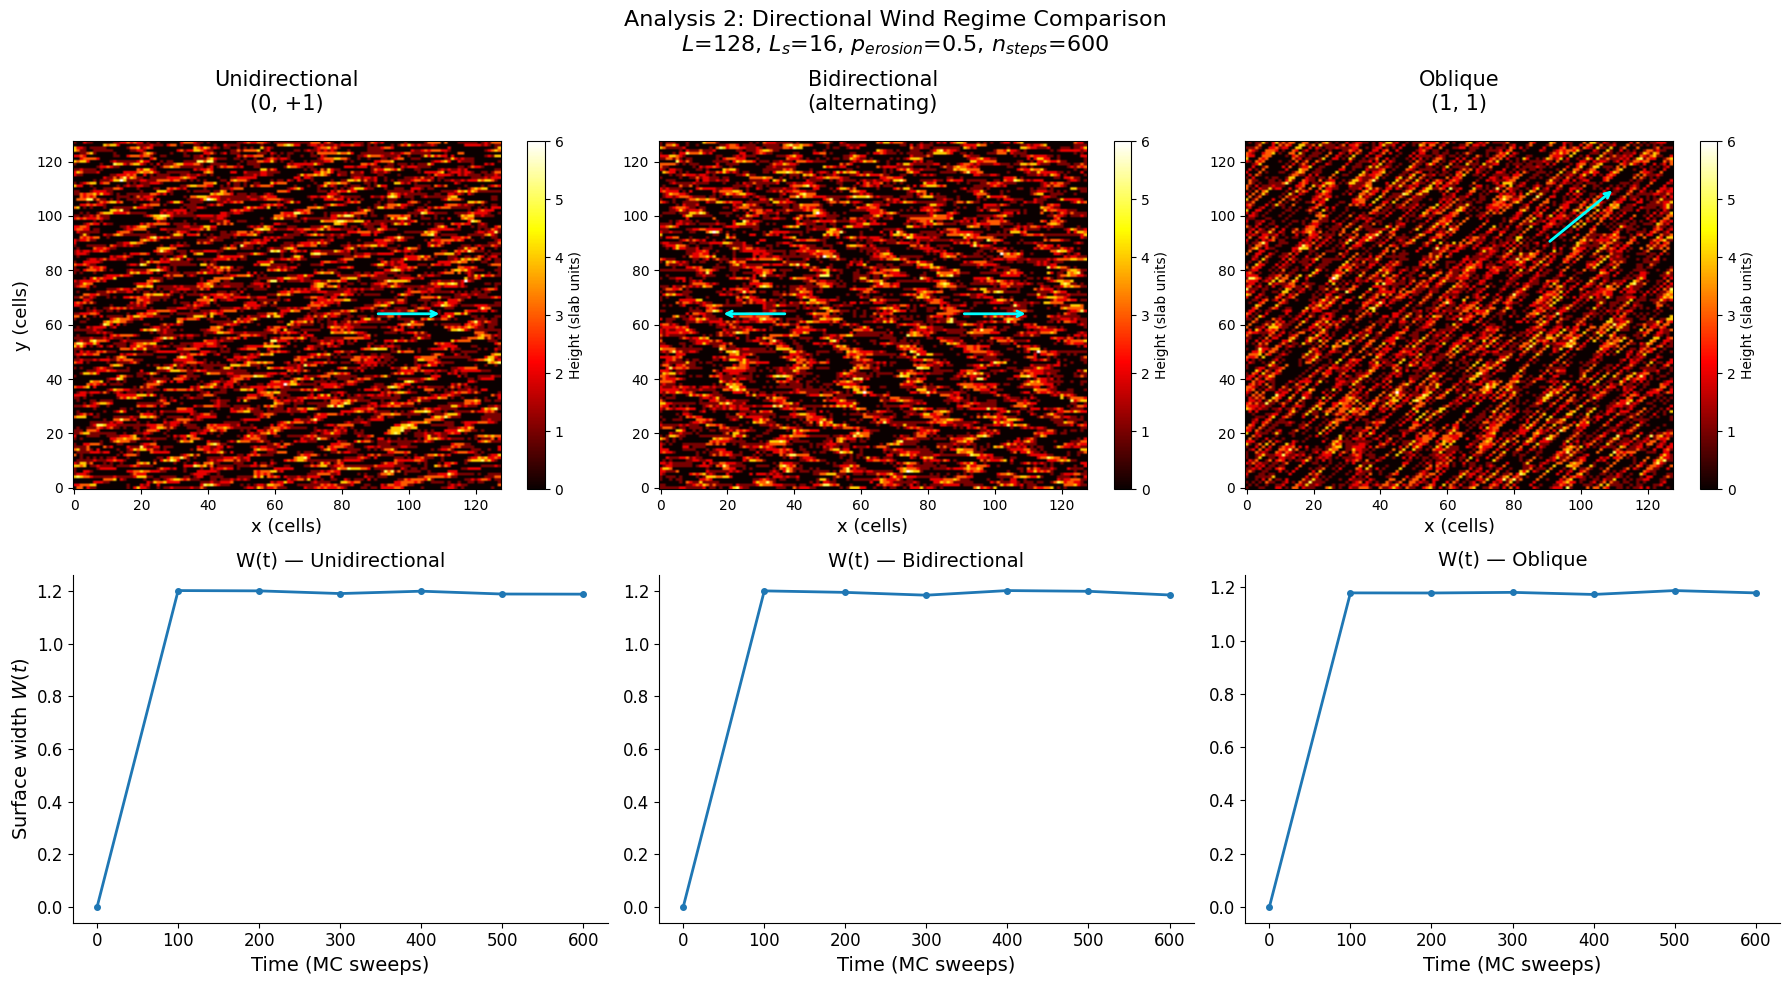

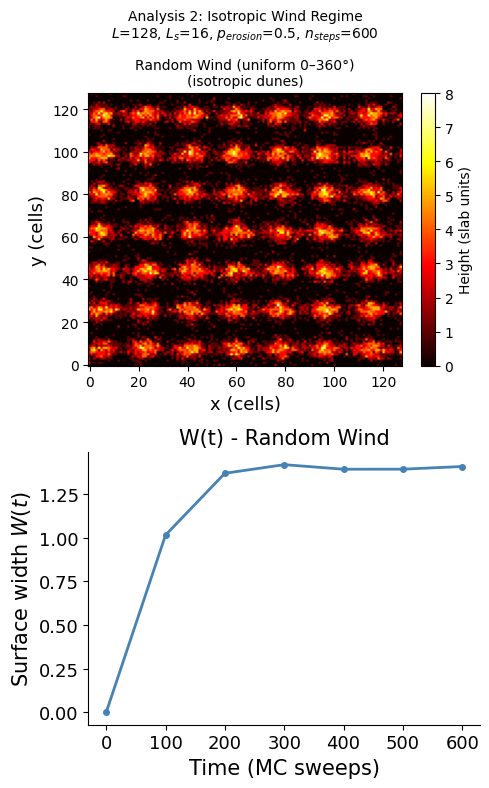

In [8]:
# Plot 1: Three directional regimes (3 columns)
regimes_3 = [
    (h_uni, w_uni, t_uni, 'Unidirectional\n(0, +1)'),
    (h_bi,  w_bi,  t_bi,  'Bidirectional\n(alternating)'),
    (h_obl, w_obl, t_obl, 'Oblique\n(1, 1)'),
]

all_heights_3 = np.concatenate([h_uni.ravel(), h_bi.ravel(), h_obl.ravel()])
vmin_3, vmax_3 = all_heights_3.min(), all_heights_3.max()

fig1, axs1 = plt.subplots(2, 3, figsize=(18, 10))

for k, (h_f, w, t, title) in enumerate(regimes_3):
    ax_top = axs1[0, k]
    im = ax_top.imshow(h_f, cmap='hot', origin='lower', aspect='auto',
                       vmin=vmin_3, vmax=vmax_3)
    ax_top.set_title(f'{title}\n', fontsize=Fontsize)
    ax_top.set_xlabel('x (cells)', fontsize=Fontsize - 2)
    if k == 0:
        ax_top.set_ylabel('y (cells)', fontsize=Fontsize - 2)
    plt.colorbar(im, ax=ax_top, label='Height (slab units)')

    arrow_props = dict(arrowstyle='->', color='cyan', lw=2)
    if k == 0:
        ax_top.annotate('', xy=(110, 64), xytext=(90, 64),
                        arrowprops=arrow_props)
    elif k == 1:
        ax_top.annotate('', xy=(110, 64), xytext=(90, 64),
                        arrowprops=arrow_props)
        ax_top.annotate('', xy=(18,  64), xytext=(38, 64),
                        arrowprops=arrow_props)
    elif k == 2:
        ax_top.annotate('', xy=(110, 110), xytext=(90, 90),
                        arrowprops=arrow_props)

    ax_bot = axs1[1, k]
    half_frame(ax_bot,
               'Time (MC sweeps)',
               'Surface width $W(t)$' if k == 0 else '',
               Fontsize - 1)
    ax_bot.plot(t, w, 'o-', lw=2, markersize=4)
    ax_bot.set_title(f'W(t) — {title.split(chr(10))[0]}',
                     fontsize=Fontsize - 1)

fig1.suptitle(
    f'Analysis 2: Directional Wind Regime Comparison\n'
    f'$L$={L_a2}, $L_s$={L_s_a2}, $p_{{erosion}}$={p_erosion_a2}, '
    f'$n_{{steps}}$={Nsteps_a2}',
    fontsize=Fontsize + 1
)
plt.tight_layout()
plt.show()


#Plot 2: Random wind regime alone
fig2, axs2 = plt.subplots(2, 1, figsize=(5, 8))

ax_map = axs2[0]
im = ax_map.imshow(h_rnd, cmap='hot', origin='lower', aspect='auto',
                   vmin=h_rnd.min(), vmax=h_rnd.max())
ax_map.set_title('Random Wind (uniform 0–360°)\n(isotropic dunes)',
                 fontsize=10)
ax_map.set_xlabel('x (cells)', fontsize=Fontsize - 2)
ax_map.set_ylabel('y (cells)', fontsize=Fontsize - 2)
plt.colorbar(im, ax=ax_map, label='Height (slab units)')

ax_wt = axs2[1]
half_frame(ax_wt, 'Time (MC sweeps)', 'Surface width $W(t)$', Fontsize)
ax_wt.plot(t_rnd, w_rnd, 'o-', lw=2, markersize=4, color='steelblue')
ax_wt.set_title('W(t) - Random Wind', fontsize=Fontsize)

fig2.suptitle(
    f'Analysis 2: Isotropic Wind Regime\n'
    f'$L$={L_a2}, $L_s$={L_s_a2}, $p_{{erosion}}$={p_erosion_a2}, '
    f'$n_{{steps}}$={Nsteps_a2}',
    fontsize=10
)
plt.tight_layout()
plt.show()

### Extra Analysis 2

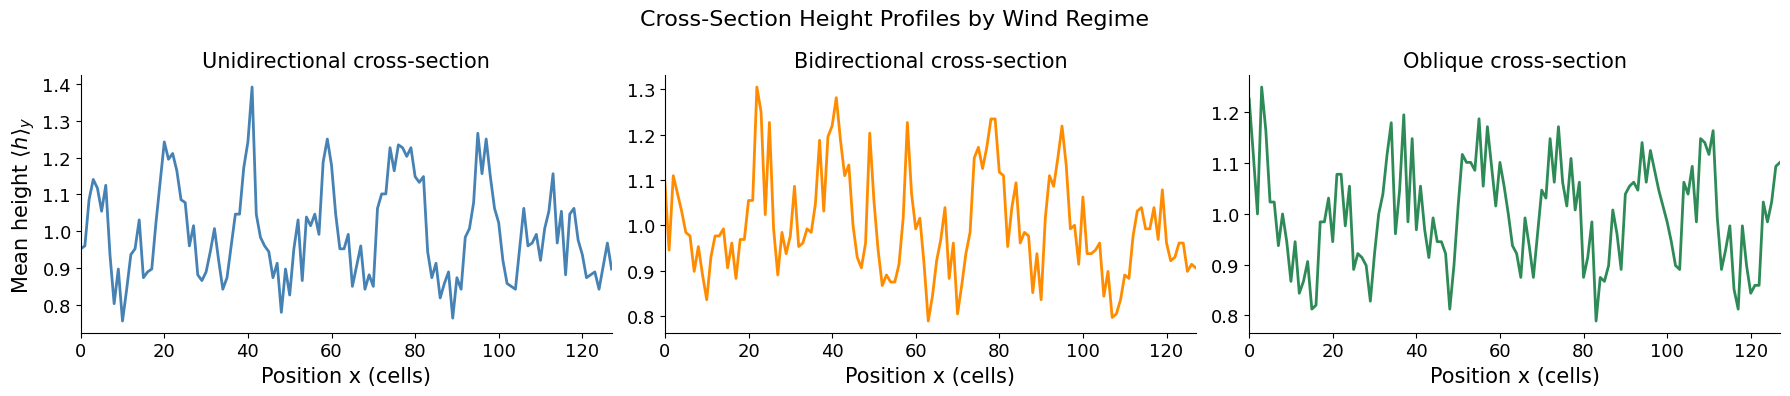


--- Analysis 2 Summary ---
Regime                 Wavelength (cells)      Final W(t)
---------------------------------------------------------
Unidirectional                       18.3            1.19
Bidirectional                        18.3            1.18
Oblique                              11.6            1.18


In [9]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))

labels   = ['Unidirectional', 'Bidirectional', 'Oblique']
surfaces = [h_uni, h_bi, h_obl]
colors   = ['steelblue', 'darkorange', 'seagreen']

for k, (h_f, label, color) in enumerate(zip(surfaces, labels, colors)):
    ax = axs[k]
    profile = np.mean(h_f, axis=0)
    half_frame(ax, 'Position x (cells)',
               'Mean height $\\langle h \\rangle_y$' if k == 0 else '',
               Fontsize)
    ax.plot(profile, '-', lw=2, color=color)
    ax.set_title(f'{label} cross-section', fontsize=Fontsize)
    ax.set_xlim(0, L_a2 - 1)

fig.suptitle('Cross-Section Height Profiles by Wind Regime', fontsize=Fontsize + 1)
plt.tight_layout()
plt.show()

# Summary table
print("\n--- Analysis 2 Summary ---")
print(f"{'Regime':<20} {'Wavelength (cells)':>20} {'Final W(t)':>15}")
print("-" * 57)
for h_f, label in zip(surfaces, labels):
    lam_k, _, _ = measure_ripple_wavelength(h_f)
    w_final = float(np.std(h_f))
    print(f"{label:<20} {lam_k:>20.1f} {w_final:>15.2f}")

### Extra Analysis 2.2 - Erosion Sweep

Running p_erosion sweep...
  p_erosion = 0.2
  p_erosion = 0.5
  p_erosion = 0.8


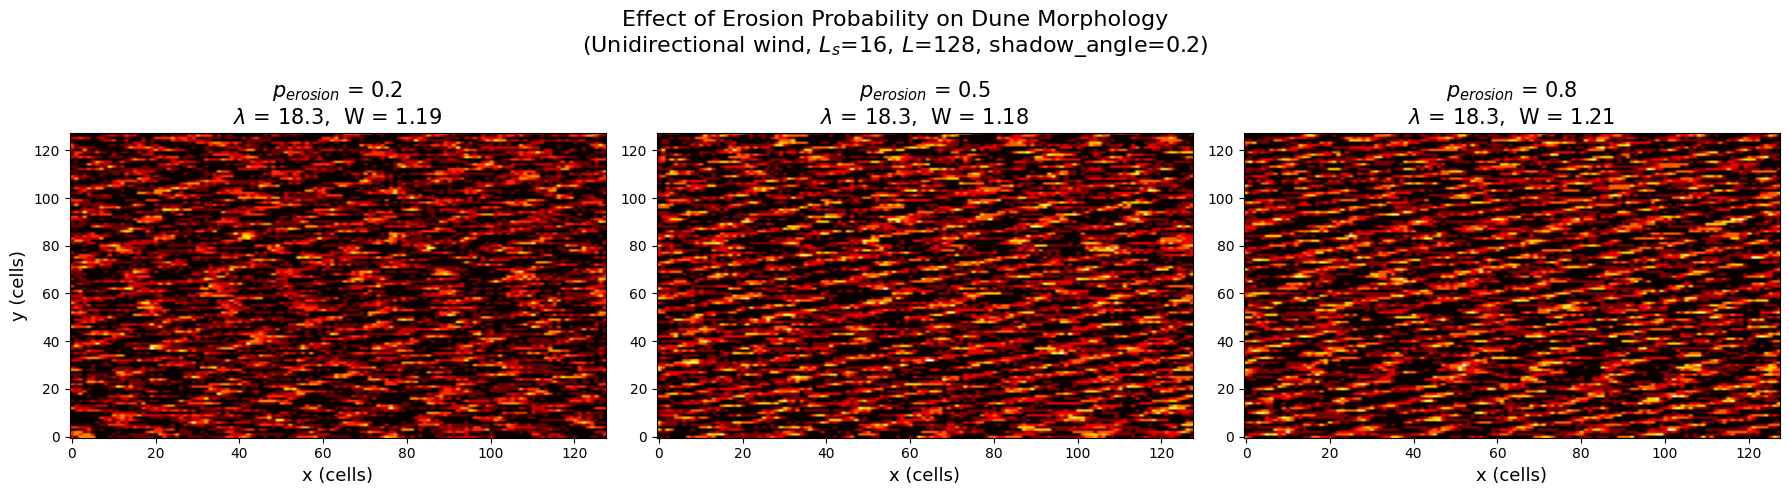

Done.


In [10]:
p_erosion_vals = [0.2, 0.5, 0.8]
h_perosion = {}
w_perosion = {}

print("Running p_erosion sweep...")
for p in p_erosion_vals:
    print(f"  p_erosion = {p}")
    h_p, _, _, _ = run_werner(
        L_a2, p, L_s_a2, (0, 1), Nsteps_a2,
        slope_threshold=slope_thr_a2,
        shadow_angle=shadow_angle,
        PdepNoShadow=PdepFlat,
        record_interval=100
    )
    h_perosion[p] = h_p
    w_perosion[p] = float(np.std(h_p))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for k, p in enumerate(p_erosion_vals):
    ax = axs[k]
    ax.imshow(h_perosion[p], cmap='hot', origin='lower', aspect='auto')
    lam_p, _, _ = measure_ripple_wavelength(h_perosion[p])
    ax.set_title(
        f'$p_{{erosion}}$ = {p}\n'
        f'$\\lambda$ = {lam_p:.1f},  W = {w_perosion[p]:.2f}',
        fontsize=Fontsize
    )
    ax.set_xlabel('x (cells)', fontsize=Fontsize - 2)
    if k == 0:
        ax.set_ylabel('y (cells)', fontsize=Fontsize - 2)

fig.suptitle(
    f'Effect of Erosion Probability on Dune Morphology\n'
    f'(Unidirectional wind, $L_s$={L_s_a2}, $L$={L_a2}, '
    f'shadow_angle={shadow_angle})',
    fontsize=Fontsize + 1
)
plt.tight_layout()
plt.show()
print("Done.")